# Init scope ablation: **global** vs **input_only** (matched pairs only)

Quick overview comparing `init_scope` from `apply_init_scale` (`a1b2/models/rnn_init.py`):
- **global**: scale all trainable parameters
- **input_only**: scale only `weight_ih*` (input-to-hidden)

We only include **matched experimental pairs** (same `dim_hidden`, `input_routing`, sparsity, `common_*`, `nb_steps`, effective `init_scale`) where **both** folders under `data/simulations/` contain at least one `sim_*.npz`. Missing `init_scale` on the global condition is treated as **`1.0`** for pairing (default init; no explicit scaling hook in `run_simulation`).

**Non-goals:** full paper figure grid, PCA — exploratory only given sparse input_only coverage.


In [1]:
# 1) Setup
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

SIMILARITY_ORDER = ["same", "near", "far"]
SIMILARITY_PALETTE = {"same": "green", "near": "orange", "far": "blue"}
PHASE_ORDER = ["post_A", "post_B", "post_A2"]

TARGET_ARCH = "two_module_rnn"
TARGET_NB_STEPS = 2
TARGET_COMMON_READOUT = True
TARGET_COMMON_INPUT = False

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann

sim_folder = project_root / "data" / "simulations"
config_path = project_root / "a1b2" / "models" / "experiments.json"
settings = json.loads(config_path.read_text())

print("Project root:", project_root)
print("Simulations:", sim_folder)


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations


In [2]:
# 2) Pair global vs input_only conditions (same experiment except scope)


def sparsity_label_from_condition(c: dict) -> str:
    sp = c.get("sparsity", 1.0)
    if sp == 0 or sp == 0.0:
        return "no_comms"
    sf = float(sp)
    return "1.0" if np.isclose(sf, 1.0) else str(sf)


def effective_init_scale(c: dict) -> float:
    v = c.get("init_scale")
    return 1.0 if v is None else float(v)


def norm_sparsity_val(sp) -> float:
    s = float(sp)
    return 0.0 if abs(s) < 1e-9 else s


def experiment_tuple(c: dict):
    """Identity for pairing (two-module RNN, paper-style grid)."""
    n_mod = int(c.get("n_modules", 2 if c.get("arch") == "two_module_rnn" else 1))
    return (
        c.get("arch"),
        int(c.get("dim_hidden", 0)),
        n_mod,
        int(c.get("nb_steps", 1)),
        str(c.get("input_routing", "shared")),
        norm_sparsity_val(c.get("sparsity", 1.0)),
        bool(c.get("common_input", False)),
        bool(c.get("common_readout", True)),
        str(c.get("cell_type", "RNN")),
        effective_init_scale(c),
    )


def passes_target_filters(c: dict) -> bool:
    if c.get("arch") != TARGET_ARCH:
        return False
    if int(c.get("nb_steps", 1)) != TARGET_NB_STEPS:
        return False
    if bool(c.get("common_readout", True)) != TARGET_COMMON_READOUT:
        return False
    if bool(c.get("common_input", False)) != TARGET_COMMON_INPUT:
        return False
    return True


def count_npz(run_path: Path) -> int:
    if not run_path.is_dir():
        return 0
    return sum(1 for p in run_path.iterdir() if p.suffix == ".npz" and p.name.startswith("sim_"))


conds = [c for c in settings["conditions"] if passes_target_filters(c)]
global_conds = [c for c in conds if c.get("init_scope", "global") != "input_only"]
io_conds = [c for c in conds if c.get("init_scope") == "input_only"]

by_key = {}
for c in global_conds:
    by_key.setdefault(experiment_tuple(c), []).append(c)

pair_rows = []
for io in io_conds:
    key = experiment_tuple(io)
    candidates = by_key.get(key, [])
    if not candidates:
        continue
    g = candidates[0]
    if len(candidates) > 1:
        print("Warning: multiple global matches for key", key, "using", g["name"])
    io_id = build_run_id(io)
    g_id = build_run_id(g)
    io_path = sim_folder / io_id
    g_path = sim_folder / g_id
    n_io = count_npz(io_path)
    n_g = count_npz(g_path)
    pair_rows.append(
        {
            "pair_key": str(key),
            "dim_hidden": io["dim_hidden"],
            "input_routing": io.get("input_routing", "shared"),
            "sparsity_label": sparsity_label_from_condition(io),
            "init_scale": effective_init_scale(io),
            "global_name": g["name"],
            "global_run_id": g_id,
            "global_npz": n_g,
            "input_only_name": io["name"],
            "input_only_run_id": io_id,
            "input_only_npz": n_io,
            "both_have_data": n_g > 0 and n_io > 0,
        }
    )

pairs_df = pd.DataFrame(pair_rows)
if pairs_df.empty:
    print("No input_only conditions matched a global counterpart.")
else:
    pairs_df = pairs_df.sort_values(
        ["dim_hidden", "input_routing", "sparsity_label", "init_scale"]
    ).reset_index(drop=True)

paired_complete = pairs_df[pairs_df["both_have_data"]].copy() if not pairs_df.empty else pd.DataFrame()
print("Pairs (config):", 0 if pairs_df.empty else len(pairs_df), "| both with ≥1 npz:", len(paired_complete))
display(pairs_df)


Pairs (config): 36 | both with ≥1 npz: 2


,pair_key,dim_hidden,input_routing,sparsity_label,init_scale,global_name,global_run_id,global_npz,input_only_name,input_only_run_id,input_only_npz,both_have_data
0,"('two_module_rnn', 12, 2, 2, 'shared', 0.5, Fa...",12,shared,0.5,0.01,two_module_rnn_12_sp05_nb2_init0.01,two_module_rnn_12_sp05_nb2_init0.01_nb2_shared...,305,two_module_rnn_12_sp05_nb2_init0.01_input_only,two_module_rnn_12_sp05_nb2_init0.01_input_only...,0,False
1,"('two_module_rnn', 12, 2, 2, 'shared', 0.5, Fa...",12,shared,0.5,0.10,two_module_rnn_12_sp05_nb2_init0.1,two_module_rnn_12_sp05_nb2_init0.1_nb2_shared_...,305,two_module_rnn_12_sp05_nb2_init0.1_input_only,two_module_rnn_12_sp05_nb2_init0.1_input_only_...,0,False
2,"('two_module_rnn', 12, 2, 2, 'shared', 0.5, Fa...",12,shared,0.5,1.00,two_module_rnn_12_sp05_nb2,two_module_rnn_12_sp05_nb2_nb2_shared_sp0.5_se...,305,two_module_rnn_12_sp05_nb2_input_only,two_module_rnn_12_sp05_nb2_input_only_nb2_shar...,0,False
3,"('two_module_rnn', 12, 2, 2, 'shared', 1.0, Fa...",12,shared,1.0,0.01,two_module_rnn_12_nb2_init0.01,two_module_rnn_12_nb2_init0.01_nb2_shared_sp1....,305,two_module_rnn_12_nb2_init0.01_input_only,two_module_rnn_12_nb2_init0.01_input_only_nb2_...,0,False
4,"('two_module_rnn', 12, 2, 2, 'shared', 1.0, Fa...",12,shared,1.0,0.10,two_module_rnn_12_nb2_init0.1,two_module_rnn_12_nb2_init0.1_nb2_shared_sp1.0...,305,two_module_rnn_12_nb2_init0.1_input_only,two_module_rnn_12_nb2_init0.1_input_only_nb2_s...,0,False
5,"('two_module_rnn', 12, 2, 2, 'shared', 1.0, Fa...",12,shared,1.0,1.00,two_module_rnn_12_nb2,two_module_rnn_12_nb2_nb2_shared_sp1.0_sep_cr_RNN,305,two_module_rnn_12_nb2_input_only,two_module_rnn_12_nb2_input_only_nb2_shared_sp...,0,False
6,"('two_module_rnn', 12, 2, 2, 'shared', 0.0, Fa...",12,shared,no_comms,0.01,two_module_rnn_12_no_comms_nb2_init0.01,two_module_rnn_12_no_comms_nb2_init0.01_nb2_sh...,305,two_module_rnn_12_no_comms_nb2_init0.01_input_...,two_module_rnn_12_no_comms_nb2_init0.01_input_...,0,False
7,"('two_module_rnn', 12, 2, 2, 'shared', 0.0, Fa...",12,shared,no_comms,0.10,two_module_rnn_12_no_comms_nb2_init0.1,two_module_rnn_12_no_comms_nb2_init0.1_nb2_sha...,305,two_module_rnn_12_no_comms_nb2_init0.1_input_only,two_module_rnn_12_no_comms_nb2_init0.1_input_o...,0,False
8,"('two_module_rnn', 12, 2, 2, 'shared', 0.0, Fa...",12,shared,no_comms,1.00,two_module_rnn_12_no_comms_nb2,two_module_rnn_12_no_comms_nb2_nb2_shared_sp0_...,305,two_module_rnn_12_no_comms_nb2_input_only,two_module_rnn_12_no_comms_nb2_input_only_nb2_...,0,False
9,"('two_module_rnn', 12, 2, 2, 'task_routed', 0....",12,task_routed,0.5,0.01,two_module_rnn_12_task_routed_sp05_nb2_init0.01,two_module_rnn_12_task_routed_sp05_nb2_init0.0...,305,two_module_rnn_12_task_routed_sp05_nb2_init0.0...,two_module_rnn_12_task_routed_sp05_nb2_init0.0...,0,False


In [3]:
# 3) Load ANN data + metrics (same pattern as paper_figures_size_comparison)


def load_all_ann_data(rows):
    """rows: iterable of dicts with run_id, init_scope_label, sparsity_label, init_scale, pairing metadata."""
    out = {}
    for row in rows:
        run_id = row["run_id"]
        path = sim_folder / run_id
        if not path.is_dir():
            continue
        ann_data = ann.load_ann_data(path)
        out[run_id] = {
            "data": ann_data,
            "init_scale": float(row["init_scale"]),
            "sparsity_label": str(row["sparsity_label"]),
            "init_scope": row["init_scope_label"],
            "dim_hidden": int(row["dim_hidden"]),
            "input_routing": row["input_routing"],
            "pair_label": row["pair_label"],
        }
    return out


def compute_metrics(all_ann_data: dict):
    transfer_records = []
    accuracy_records = []

    for run_id, bundle in all_ann_data.items():
        ann_data = bundle["data"]
        init_scale = bundle["init_scale"]
        sp_label = bundle["sparsity_label"]
        scope = bundle["init_scope"]
        dh = bundle["dim_hidden"]
        routing = bundle["input_routing"]
        pair_label = bundle["pair_label"]

        for cond_name, entries in ann_data.items():
            if cond_name not in SIMILARITY_ORDER:
                continue
            for entry in entries:
                pid = str(entry.get("participant"))

                acc = np.asarray(entry["accuracy"])
                if acc.ndim == 3:
                    cond_idx = SIMILARITY_ORDER.index(cond_name)
                    acc_cond = acc[cond_idx]
                else:
                    acc_cond = acc

                if acc_cond.ndim >= 2 and acc_cond.shape[0] >= 2:
                    A1_acc = acc_cond[0, 1::2]
                    B_acc = acc_cond[1, 1::2]
                    if len(A1_acc) >= 6 and len(B_acc) >= 6:
                        final_A1 = float(np.mean(A1_acc[-6:]))
                        init_B = float(np.mean(B_acc[:6]))
                        transfer_records.append(
                            {
                                "run_id": run_id,
                                "init_scope": scope,
                                "init_scale": init_scale,
                                "sparsity_label": sp_label,
                                "condition": cond_name,
                                "participant": pid,
                                "error_diff": init_B - final_A1,
                                "dim_hidden": dh,
                                "input_routing": routing,
                                "pair_label": pair_label,
                            }
                        )

                n_ph = acc_cond.shape[0]
                for ph in range(min(3, n_ph)):
                    phase_name = PHASE_ORDER[ph]
                    accuracy_records.append(
                        {
                            "run_id": run_id,
                            "init_scope": scope,
                            "init_scale": init_scale,
                            "sparsity_label": sp_label,
                            "condition": cond_name,
                            "participant": pid,
                            "phase": phase_name,
                            "mean_accuracy": float(np.nanmean(acc_cond[ph])),
                            "dim_hidden": dh,
                            "input_routing": routing,
                            "pair_label": pair_label,
                        }
                    )

    return (
        pd.DataFrame(transfer_records),
        pd.DataFrame(accuracy_records),
    )


run_rows = []
if not paired_complete.empty:
    for _, r in paired_complete.iterrows():
        plab = f"h{r['dim_hidden']}_{r['input_routing']}_sp{r['sparsity_label']}_init{r['init_scale']}"
        run_rows.append(
            {
                "run_id": r["global_run_id"],
                "init_scope_label": "global",
                "sparsity_label": r["sparsity_label"],
                "init_scale": r["init_scale"],
                "dim_hidden": r["dim_hidden"],
                "input_routing": r["input_routing"],
                "pair_label": plab,
            }
        )
        run_rows.append(
            {
                "run_id": r["input_only_run_id"],
                "init_scope_label": "input_only",
                "sparsity_label": r["sparsity_label"],
                "init_scale": r["init_scale"],
                "dim_hidden": r["dim_hidden"],
                "input_routing": r["input_routing"],
                "pair_label": plab,
            }
        )

all_ann = load_all_ann_data(run_rows)
transfer_df, acc_df = compute_metrics(all_ann)

print("Loaded runs:", len(all_ann))
print("transfer rows:", transfer_df.shape, "| acc rows:", acc_df.shape)
if not transfer_df.empty:
    display(transfer_df.groupby(["pair_label", "init_scope"])["participant"].nunique().unstack(fill_value=0))


Loaded runs: 4
transfer rows: (1220, 10) | acc rows: (3660, 11)


init_scope,global,input_only
pair_label,,
h12_task_routed_sp0.5_init0.1,305,305
h12_task_routed_sp0.5_init1.0,305,305


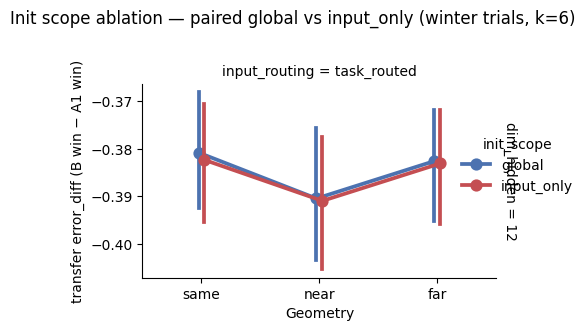

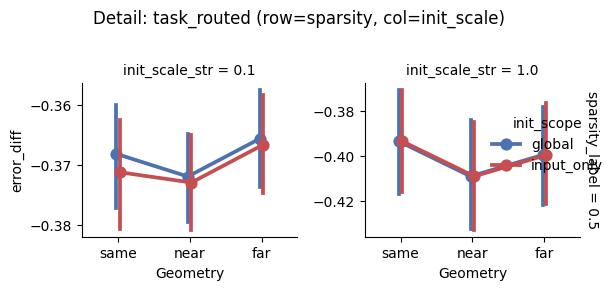

In [4]:
# 4) Figure A — paper-faithful transfer (winter): mean first 6 B − mean last 6 A1 (error_diff)

if transfer_df.empty:
    print("No transfer metric rows; check paired_complete and .npz files.")
else:
    plot_df = transfer_df.copy()
    plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=SIMILARITY_ORDER, ordered=True)
    plot_df["init_scale_str"] = plot_df["init_scale"].map(lambda x: str(x))

    g = sns.catplot(
        data=plot_df,
        x="condition",
        y="error_diff",
        hue="init_scope",
        hue_order=["global", "input_only"],
        palette={"global": "#4c72b0", "input_only": "#c44e52"},
        kind="point",
        dodge=True,
        col="input_routing",
        row="dim_hidden",
        margin_titles=True,
        sharey=False,
        height=3.2,
        aspect=1.1,
    )
    g.set_axis_labels("Geometry", "transfer error_diff (B win − A1 win)")
    g.fig.suptitle("Init scope ablation — paired global vs input_only (winter trials, k=6)", y=1.02)
    plt.tight_layout()
    plt.show()

    for routing in plot_df["input_routing"].unique():
        sub = plot_df[plot_df["input_routing"] == routing]
        if sub.empty:
            continue
        g2 = sns.catplot(
            data=sub,
            x="condition",
            y="error_diff",
            hue="init_scope",
            hue_order=["global", "input_only"],
            palette={"global": "#4c72b0", "input_only": "#c44e52"},
            kind="point",
            dodge=True,
            col="init_scale_str",
            row="sparsity_label",
            margin_titles=True,
            sharey=False,
            height=2.8,
            aspect=0.9,
        )
        g2.set_axis_labels("Geometry", "error_diff")
        g2.fig.suptitle(f"Detail: {routing} (row=sparsity, col=init_scale)", y=1.02)
        plt.tight_layout()
        plt.show()


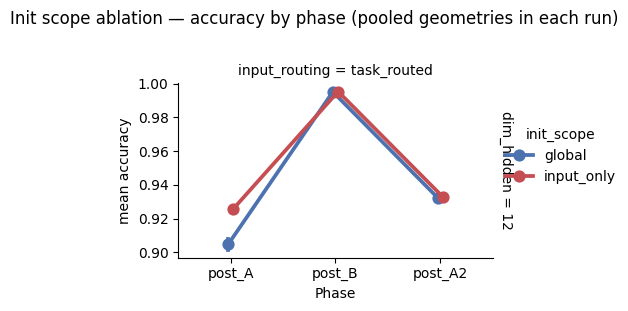

In [5]:
# 5) Figure B — mean accuracy by phase (all trials; not winter-only)

if acc_df.empty:
    print("No accuracy rows.")
else:
    ad = acc_df.copy()
    ad["phase"] = pd.Categorical(ad["phase"], categories=PHASE_ORDER, ordered=True)
    ad["init_scale_str"] = ad["init_scale"].map(lambda x: str(x))

    g = sns.catplot(
        data=ad,
        x="phase",
        y="mean_accuracy",
        hue="init_scope",
        hue_order=["global", "input_only"],
        palette={"global": "#4c72b0", "input_only": "#c44e52"},
        kind="point",
        dodge=True,
        col="input_routing",
        row="dim_hidden",
        margin_titles=True,
        sharey=False,
        height=3.0,
        aspect=1.0,
    )
    g.set_axis_labels("Phase", "mean accuracy")
    g.fig.suptitle("Init scope ablation — accuracy by phase (pooled geometries in each run)", y=1.02)
    plt.tight_layout()
    plt.show()
